In [3]:
import os
import json
import time

import cv2
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import torch
from vidgear.gears import WriteGear

from koger_detection.obj_det.mydatasets import VideoDataset
from koger_detection.obj_det.predictors import Predictor

In [4]:
load_dotenv()

True

In [5]:
#video_name = "bear_big2a_2023_08_16_koger_01_05_DJI_20230816175814_0573_D"

video_name = "clipped_23_8"
video_folder = os.path.join(os.environ.get("PROJECT_DROPBOX"), "media")
video_file = os.path.join(video_folder, video_name + ".mp4")

if os.path.exists(video_file):
    print(f"video exists")

out_folder = os.path.join(os.environ.get("PROJECT_DROPBOX"), video_name)
os.makedirs(out_folder, exist_ok=True)

out_name = "test.mp4"


create_video = False

video exists


In [19]:
out_folder

'/home/berdahl/Dropbox/bear-hunting/clipped_23_8'

In [6]:
video_file

'/home/berdahl/Dropbox/bear-hunting/media/clipped_23_8.mp4'

In [7]:
#run_folder = os.path.join(os.environ.get("MODEL_PATH"), "models", "runs", "main")
run_folder = os.path.join(os.environ.get("MODEL_PATH"), "bear_hunting", "runs", "main")
run_name = "04-17-2026-15-19-02"
cfg_file = os.path.join(run_folder, run_name, "cfg.json") 

with open(cfg_file, "r") as f:
    cfg = json.load(f)
    
cfg_m = cfg['model']
cfg_m['model_weights_pth'] = os.path.join(run_folder, run_name, "final_model.pth")
cfg_m['box_detections_per_img'] = 512
cfg_m['rpn_pre_nms_top_n_test'] = 4000
cfg_m['rpn_post_nms_top_n_test'] = 2000

In [8]:

predictor = Predictor(cfg_m)

In [9]:
ds = VideoDataset(video_file)
data_loader = torch.utils.data.DataLoader(ds, batch_size=1, num_workers=0)

if create_video:
    output_params = {"-input_framerate": 30,
                    "-pix_fmt": "yuv420p"}
    writer = WriteGear(output=os.path.join(out_folder, out_name),
                    **output_params) 


all_boxes = []
all_scores = []
all_labels = []

t0 = time.time()
first_frame = 0
max_im = None # 10000
for ind, f in enumerate(data_loader):
    if ind < first_frame:
        continue
    if max_im is not None:
        if ind >= max_im:
            break
    if ind % 1000 == 0:
        print(f"Frame number {ind} processed.")
    res = predictor(f[0])
    boxes = res['boxes'].to('cpu').numpy().astype(np.uint32)
    scores = res['scores'].to('cpu').numpy()
    labels = res['labels'].to('cpu').numpy()

    image_name = f"{video_name}-frame-{ind}"

    all_boxes.append(boxes)
    all_scores.append(scores)
    all_labels.append(labels)

    if create_video:
        frame = f[0].numpy().copy() # Copy makes circle work for unclear reasons
        
        for box, score, label in zip(boxes, scores, labels):
            if score < .9:
                continue
            x = np.mean([box[0], box[2]])
            y = np.mean([box[1], box[3]])
            if label == 1:
                cv2.circle(frame, [int(x), int(y)], 4, (4,217,255), -1)
            else:
                cv2.circle(frame, [int(x), int(y)], 8, (255, 0, 0), -1)
        if frame is not None:
            writer.write(frame, rgb_mode=True)
        else:
            print("skipping.")
ds.stop()   
if create_video: 
    writer.close()
total_time = time.time() - t0
print(total_time, f"fps: {ind / total_time}", f"{ind} frames processed.")

np.savez_compressed(os.path.join(out_folder, f"{video_name}-boxes.npz"), *all_boxes)
np.savez_compressed(os.path.join(out_folder, f"{video_name}-scores.npz"), *all_scores)
np.savez_compressed(os.path.join(out_folder, f"{video_name}-labels.npz"), *all_labels)

Frame number 0 processed.
Empty frame. Ending stream.
FileVideoStream stopped.
43.111491203308105 fps: 4.430373310430604 191 frames processed.


In [10]:
from yolox.tracker.byte_tracker import BYTETracker

In [20]:
class BearArguments:
    def __init__(self):
        self.track_thresh = 0.6
        self.track_buffer = 30
        self.match_thresh = 0.8
        self.min_box_area = 10
        self.frame_rate = 30
        self.mot20 = False
        self.track_id = True
        self.nms = 0.65

bear_args = BearArguments()

class SalmonArguments:
    def __init__(self):
        self.track_thresh = 0.5 #0.85
        self.track_buffer = 3
        self.match_thresh = 0.8
        self.min_box_area = 10
        self.frame_rate = 30
        self.mot20 = False
        self.track_id = True
        self.nms = 0.65

salmon_args = SalmonArguments()

In [21]:
#args.track_thresh

In [22]:
import pickle

In [23]:
tracker = BYTETracker(salmon_args)

boxes = []
z_boxes = np.load(os.path.join(out_folder, f"{video_name}-boxes.npz"))
z_scores = np.load(os.path.join(out_folder, f"{video_name}-scores.npz"))
z_labels = np.load(os.path.join(out_folder, f"{video_name}-labels.npz"))

tracks = {}

class_to_track = 2 # 1 is bear, 2 is salmon

frame_num = 0
for boxes_key, scores_key, labels_key in zip(z_boxes, z_scores, z_labels):
    dets = np.concatenate([z_boxes[boxes_key], 
                           z_scores[scores_key][:, np.newaxis], 
                           z_scores[scores_key][:, np.newaxis],
                           z_labels[labels_key][:, np.newaxis]
                           ], 
                           axis=1)
    dets = dets[dets[:,-1]==class_to_track]
    online_targets = tracker.update(torch.from_numpy(dets), [2160, 3840], [2160, 3840])

    for strack in online_targets:
        if strack.is_activated:
            track_id = strack.track_id
            if track_id not in tracks:
                tracks[track_id] = {}
            tracks[track_id][strack.frame_id] = strack.tlwh

with open(os.path.join(out_folder, f'{video_name}-tracks-class-{class_to_track}.pkl'), 'wb') as outp:
    pickle.dump(tracks, outp, pickle.HIGHEST_PROTOCOL)
    print("we made it to pickle")


we made it to pickle


In [25]:
test = pickle.load(open(os.path.join(out_folder, f'{video_name}-tracks-class-{class_to_track}.pkl'), 'rb'))


(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.]),
 array([ 67.  ,  68.25,  69.5 ,  70.75,  72.  ,  73.25,  74.5 ,  75.75,
         77.  ,  78.25,  79.5 ,  80.75,  82.  ,  83.25,  84.5 ,  85.75,
         87.  ,  88.25,  89.5 ,  90.75,  92.  ,  93.25,  94.5 ,  95.75,
         97.  ,  98.25,  99.5 , 100.75, 102.  , 103.25, 104.5 , 105.75,
        107.  , 108.25, 109.5 , 110.75, 112.  , 113.25, 114.5 , 115.75,
        117.  , 118.25, 119.5 , 120.75, 122.  , 123.25, 124.5 , 125.75,
        127.  , 128.25, 129.5 , 130.75, 132.  , 133.25, 134.5 , 135.75,
        137.  , 138.25, 139.5 , 140.75, 142.  

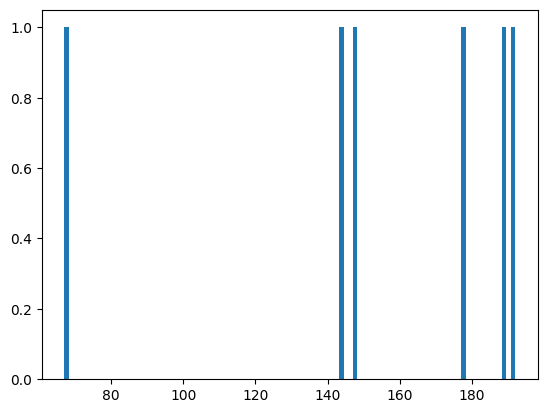

In [26]:
tracks_length = []
for track_id, track in tracks.items():
    if len(track) > 10:
        tracks_length.append(len(track))
plt.hist(tracks_length, bins=100)


In [27]:

import matplotlib as mpl

In [28]:
cmap = mpl.colormaps['tab20']
colors = [(np.array(c) * 255) for c in cmap.colors]


In [29]:
ds = VideoDataset(video_file)
data_loader = torch.utils.data.DataLoader(ds, batch_size=1, num_workers=0)
out_name = "test-track-2.mp4"

output_params = {"-input_framerate": 30,
                "-pix_fmt": "yuv420p"}
writer = WriteGear(output=os.path.join(out_folder, out_name),
                **output_params) 

t0 = time.time()
first_frame = 0
max_im = None # 10000
for ind, f in enumerate(data_loader):
    if ind < first_frame:
        continue
    if max_im is not None:
        if ind >= max_im:
            break
    if ind % 1000 == 0:
        print(f"Frame number {ind} processed.")

    frame = f[0].numpy().copy() # Copy makes circle work for unclear reasons

    for track_id, track in tracks.items():
        if ind in track:
            box = track[ind]
            x = box[0] + int(box[2] / 2)
            y = box[1] + int(box[3] / 2)
            color = colors[track_id % len(colors)]
            cv2.circle(frame, [int(x), int(y)], 8, (int(color[0]), int(color[1]), int(color[2])), -1)
            cv2.putText(frame, str(track_id), (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
    if frame is not None:
        writer.write(frame, rgb_mode=True)
    else:
        print("skipping.")

    if ind > 20000:
        break
ds.stop()   

writer.close()
total_time = time.time() - t0
print(total_time, f"fps: {ind / total_time}", f"{ind} frames processed.")

15:49:03 ::   WriteGear   :: WARNING  :: Optional `-disable_ffmpeg_window` flag is only available on Windows OS with `logging=False`. Discarding!


Frame number 0 processed.
Empty frame. Ending stream.
FileVideoStream stopped.
7.153205871582031 fps: 26.70131454748103 191 frames processed.
